<a href="https://colab.research.google.com/github/hykim-1/Study/blob/main/SimpleCNN_smartphone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np
import pandas as pd
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras import layers
import tensorflow as tf
from sklearn.metrics import f1_score, classification_report, accuracy_score, confusion_matrix

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)

In [15]:
def load_file(filepath):
    dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
    return dataframe.values

def load_group(filenames, prefix=''):
    loaded = list()
    for name in filenames:
        data = load_file(prefix + name)
        loaded.append(data)
    loaded = np.dstack(loaded)    # (N, 128, 9)
    return loaded

def load_dataset_group(group, prefix=''):
    filepath = prefix + group + '/Inertial Signals/'
    filenames = list()
    filenames += ['total_acc_x_'+group+'.txt', 'total_acc_y_'+group+'.txt', 'total_acc_z_'+group+'.txt']
    filenames += ['body_acc_x_'+group+'.txt', 'body_acc_y_'+group+'.txt', 'body_acc_z_'+group+'.txt']
    filenames += ['body_gyro_x_'+group+'.txt', 'body_gyro_y_'+group+'.txt', 'body_gyro_z_'+group+'.txt']
    X = load_group(filenames, filepath)
    y = load_file(prefix + group + '/y_'+group+'.txt')
    return X, y

def load_dataset(prefix=''):
    base = '/content/drive/MyDrive/Colab Notebooks/UCI HAR Dataset/UCI HAR Dataset/'
    trainX, trainy = load_dataset_group('train', base)
    testX,  testy  = load_dataset_group('test',  base)
    trainy = trainy - 1
    testy  = testy - 1
    trainy_one_hot = to_categorical(trainy)
    testy_one_hot  = to_categorical(testy)
    print("Shapes:",
          "trainX", trainX.shape, "trainy", trainy.shape, "trainy_oh", trainy_one_hot.shape,
          "| testX", testX.shape, "testy", testy.shape, "testy_oh", testy_one_hot.shape)
    return trainX, trainy, trainy_one_hot, testX, testy, testy_one_hot

trainX, trainy, trainy_one_hot, testX, testy, testy_one_hot = load_dataset()

num_classes = trainy_one_hot.shape[1]
timesteps  = trainX.shape[1]   # 128
n_channels = trainX.shape[2]   # 9
input_shape = (timesteps, n_channels)

/tmp/ipython-input-4258388345.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-4258388345.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-4258388345.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-4258388345.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)


Shapes: trainX (7352, 128, 9) trainy (7352, 1) trainy_oh (7352, 6) | testX (2947, 128, 9) testy (2947, 1) testy_oh (2947, 6)


/tmp/ipython-input-4258388345.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-4258388345.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)


In [16]:
# ===== Simple 1D-CNN =====
def build_simple_cnn(input_shape, num_classes):
    inp = keras.Input(shape=input_shape)
    x = layers.Conv1D(64, 5, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inp, out, name="SimpleCNN")

model = build_simple_cnn(input_shape, num_classes)
model.summary()

Model: "SimpleCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 128, 64)        │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 64, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,702 (178.52 KB)

 Trainable params: 45,318 (177.02 KB)

 Non-trainable params: 384 (1.50 KB)

In [17]:
# ===== 학습 (train만) =====
opt = keras.optimizers.Adam(1e-3)
model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])
callbacks = [
    keras.callbacks.EarlyStopping(monitor="loss", patience=3, restore_best_weights=True)
]
history = model.fit(
    trainX, trainy_one_hot,
    epochs=30, batch_size=64, verbose=2,
    callbacks=callbacks
)

Epoch 1/30
115/115 - 6s - 49ms/step - accuracy: 0.8890 - loss: 0.3173
Epoch 2/30
115/115 - 0s - 4ms/step - accuracy: 0.9483 - loss: 0.1321
Epoch 3/30
115/115 - 0s - 4ms/step - accuracy: 0.9489 - loss: 0.1202
Epoch 4/30
115/115 - 1s - 4ms/step - accuracy: 0.9518 - loss: 0.1131
Epoch 5/30
115/115 - 1s - 5ms/step - accuracy: 0.9523 - loss: 0.1088
Epoch 6/30
115/115 - 0s - 4ms/step - accuracy: 0.9516 - loss: 0.1057
Epoch 7/30
115/115 - 1s - 5ms/step - accuracy: 0.9525 - loss: 0.1020
Epoch 8/30
115/115 - 1s - 5ms/step - accuracy: 0.9540 - loss: 0.1019
Epoch 9/30
115/115 - 0s - 4ms/step - accuracy: 0.9570 - loss: 0.0952
Epoch 10/30
115/115 - 0s - 3ms/step - accuracy: 0.9587 - loss: 0.0921
Epoch 11/30
115/115 - 0s - 3ms/step - accuracy: 0.9614 - loss: 0.0874
Epoch 12/30
115/115 - 0s - 3ms/step - accuracy: 0.9626 - loss: 0.0857
Epoch 13/30
115/115 - 0s - 3ms/step - accuracy: 0.9615 - loss: 0.0856
Epoch 14/30
115/115 - 0s - 3ms/step - accuracy: 0.9631 - loss: 0.0854
Epoch 15/30
115/115 - 0s - 3

In [18]:
# ===== 평가 (test) =====
test_probs = model.predict(testX, verbose=0)
test_pred  = test_probs.argmax(axis=1)
test_true  = testy.flatten()
test_acc   = accuracy_score(test_true, test_pred)
test_f1    = f1_score(test_true, test_pred, average="macro")

print(f"[TEST] Acc={test_acc:.4f} | Macro-F1={test_f1:.4f}")
print("\n[TEST] Classification Report")
print(classification_report(test_true, test_pred, digits=4))

[TEST] Acc=0.9223 | Macro-F1=0.9233

[TEST] Classification Report
              precision    recall  f1-score   support

           0     1.0000    0.9940    0.9970       496
           1     0.8887    0.9490    0.9179       471
           2     0.9395    0.9976    0.9677       420
           3     0.8077    0.8554    0.8309       491
           4     0.9032    0.8064    0.8520       532
           5     1.0000    0.9497    0.9742       537

    accuracy                         0.9223      2947
   macro avg     0.9232    0.9254    0.9233      2947
weighted avg     0.9241    0.9223    0.9222      2947



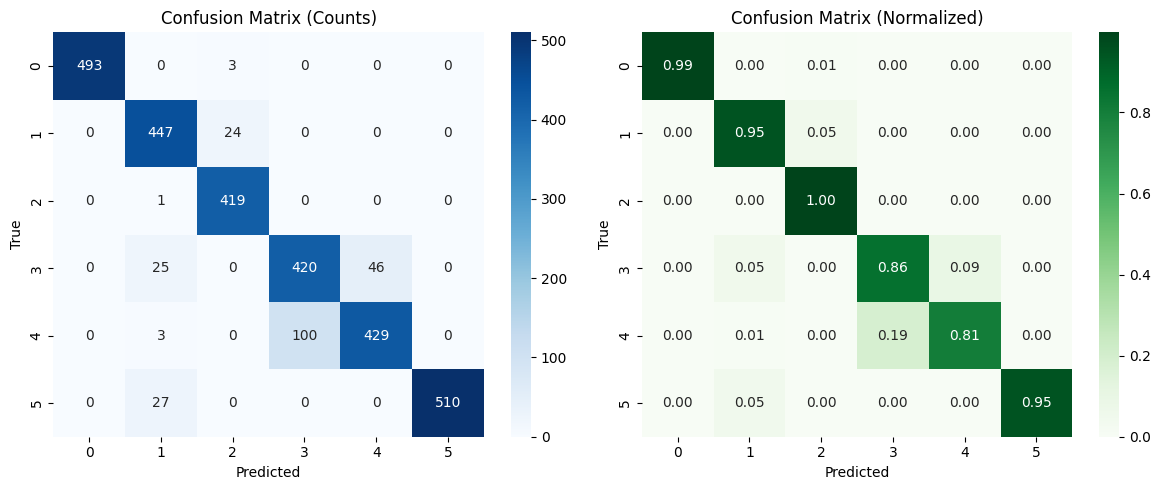

In [19]:
# ===== 시각화 (BMI 노트북 느낌: 혼동행렬 + 학습곡선 + 클래스별 F1) =====

# 1) 혼동행렬(정수 & 정규화)
cm = confusion_matrix(test_true, test_pred)              # 정수
cm_norm = confusion_matrix(test_true, test_pred, normalize='true')  # 행 정규화

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Counts)')
plt.xlabel('Predicted'); plt.ylabel('True')

plt.subplot(1,2,2)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens')
plt.title('Confusion Matrix (Normalized)')
plt.xlabel('Predicted'); plt.ylabel('True')

plt.tight_layout()
plt.show()

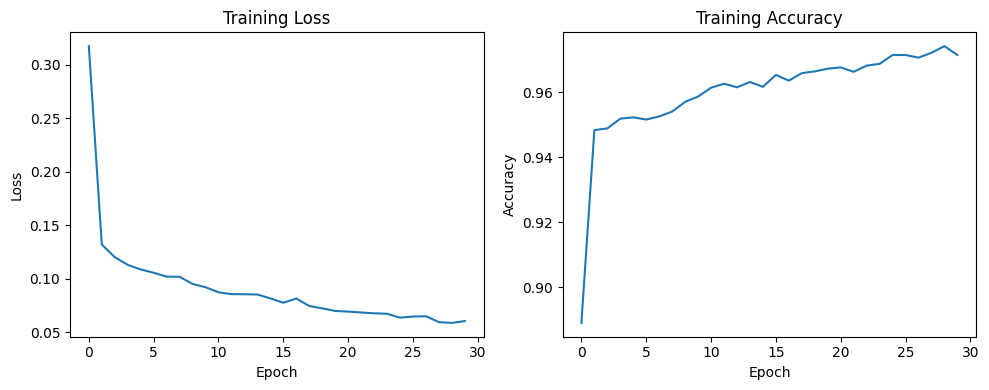

In [20]:
# 2) 학습 곡선 (훈련 loss/acc) — train/test만 쓰므로 val 곡선 없음
hist = history.history
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(hist.get('loss', []))
plt.title('Training Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss')

plt.subplot(1,2,2)
plt.plot(hist.get('accuracy', []))
plt.title('Training Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()

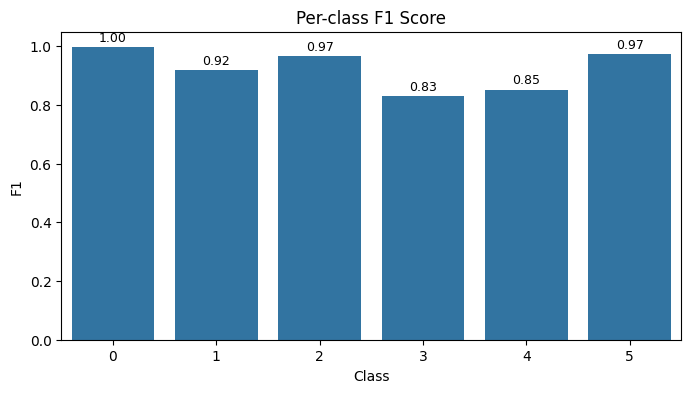


TF: 2.19.0 | Keras: 3.10.0 | Backend: tensorflow


In [21]:
# 3) 클래스별 F1 bar plot
#   classification_report에서 per-class F1을 꺼내 그래프로
from sklearn.metrics import precision_recall_fscore_support
prec, rec, f1s, support = precision_recall_fscore_support(test_true, test_pred, zero_division=0)
classes = np.arange(len(f1s))

plt.figure(figsize=(8,4))
sns.barplot(x=classes, y=f1s)
plt.title('Per-class F1 Score'); plt.xlabel('Class'); plt.ylabel('F1')
for i, v in enumerate(f1s):
    plt.text(i, v+0.01, f"{v:.2f}", ha='center', va='bottom', fontsize=9)
plt.ylim(0, 1.05)
plt.show()

print("\nTF:", tf.__version__, "| Keras:", keras.__version__, "| Backend:", keras.backend.backend())
